# Applied Machine Learning: Train and test set, cross-validation

## Preamble and Review

In [1]:
#Librerías
%matplotlib notebook
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [2]:
#Para que a la hora de imprimir haya dos dígitos
np.set_printoptions(precision=2)
#Lectura de datos
fruits = pd.read_table('C://trabajo 2022//Python//Applied Machine Learning in Python//fruit_data_with_colors.txt')
fruits

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79
5,2,mandarin,mandarin,80,5.8,4.3,0.77
6,2,mandarin,mandarin,80,5.9,4.3,0.81
7,2,mandarin,mandarin,76,5.8,4.0,0.81
8,1,apple,braeburn,178,7.1,7.8,0.92
9,1,apple,braeburn,172,7.4,7.0,0.89


In [4]:
#Subconjunto de variables que se usaran como input
feature_names_fruits = ['height', 'width', 'mass', 'color_score']
X_fruits = fruits[feature_names_fruits]
X_fruits

,height,width,mass,color_score
0,7.3,8.4,192,0.55
1,6.8,8.0,180,0.59
2,7.2,7.4,176,0.60
3,4.7,6.2,86,0.80
4,4.6,6.0,84,0.79
5,4.3,5.8,80,0.77
6,4.3,5.9,80,0.81
7,4.0,5.8,76,0.81
8,7.8,7.1,178,0.92
9,7.0,7.4,172,0.89


In [5]:
#Variable de output como etiquetas 
y_fruits = fruits['fruit_label']
#Valores asociados a cada etiqueta
target_names_fruits = ['apple', 'mandarin', 'orange', 'lemon']
target_names_fruits

['apple', 'mandarin', 'orange', 'lemon']

In [6]:
#Selección de solo dos variables input que se usa en regresión logística abajo
X_fruits_2d = fruits[['height', 'width']]
y_fruits_2d = fruits['fruit_label']
print(type(X_fruits_2d))
X_fruits_2d

<class 'pandas.core.frame.DataFrame'>


,height,width
0,7.3,8.4
1,6.8,8.0
2,7.2,7.4
3,4.7,6.2
4,4.6,6.0
5,4.3,5.8
6,4.3,5.9
7,4.0,5.8
8,7.8,7.1
9,7.0,7.4


In [7]:
#División en muestras de prueba y entrenamiento, por default 75% de entrenamiento, con semilla de cero
X_train, X_test, y_train, y_test = train_test_split(X_fruits, y_fruits, random_state=0)

In [8]:
#Importar librería para rescalar cada variable tipo input, usando una variable rescalada 
#entre 0 y 1 de acuerdo al máximo y al mínimo. Primero para los elementos de la muestra de entrenamiento
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
#Ahora sobre la muestra de prueba
# we must apply the scaling to the test set that we computed for the training set
X_test_scaled = scaler.transform(X_test)
X_test_scaled #Vemos como van entre 0 y 1

array([[0.8 , 1.12, 1.02, 0.51],
       [0.6 , 0.38, 0.26, 0.54],
       [0.97, 0.41, 0.42, 0.41],
       [0.48, 0.26, 0.23, 0.46],
       [0.55, 0.38, 0.34, 1.  ],
       [0.49, 0.47, 0.36, 0.14],
       [0.58, 0.53, 0.24, 0.54],
       [0.95, 0.44, 0.5 , 0.43],
       [0.54, 0.38, 0.28, 0.62],
       [0.48, 0.44, 0.23, 0.86],
       [0.09, 0.06, 0.03, 0.65],
       [0.51, 0.32, 0.32, 1.03],
       [0.54, 0.38, 0.29, 0.65],
       [0.65, 0.53, 0.37, 0.65],
       [0.63, 0.5 , 0.41, 0.51]])

In [9]:
#K vecinos más cercanos con k=5
knn = KNeighborsClassifier(n_neighbors = 5) 
#Ajuste sobre la muestra de prueba 
knn.fit(X_train_scaled, y_train)
#Precisión (% correctamente clasificados) sobre la muestra de entrenamiento
print('Accuracy of K-NN classifier on training set: {:.2f}' #Damos que la precición del flotante sea 2 dígitos
     .format(knn.score(X_train_scaled, y_train))) #Precisión del puntaje usando el ajuste knn y el score generado de la muestra
#de prueba sobre la muestra de entrenamiento
#Similar sobre la muestra de prueba
print('Accuracy of K-NN classifier on test set: {:.2f}'
     .format(knn.score(X_test_scaled, y_test)))

Accuracy of K-NN classifier on training set: 0.95
Accuracy of K-NN classifier on test set: 1.00


In [10]:
#Ejemplo de una fruta diferente
example_fruit = [[5.5, 2.2, 10, 0.70]] #Si usamos tal cual esta lista da un warning porque no vienen las etiquetas
#de cada variable
print(type(example_fruit))#Tipo del objeto
#convert list to DataFrame, columns son los nombres de cada variable
df = pd.DataFrame(example_fruit, columns=['height', 'width', 'mass', 'color_score'])
print(type(df))#Tipo del objeto
#Rescalar los colores de esa fruta
example_fruit_scaled = scaler.transform(df)
#Imprimir la fruta con palabras
print('Predicted fruit type for ', example_fruit, ' is ', 
          target_names_fruits[knn.predict(example_fruit_scaled)[0]-1])#knn.predict(example_fruit_scaled)[0] es la etiqueta
#de la fruta según el clasificador, esta va de 1 a 4, pero dado que queremos ver cuál es el nombre real y  en target_names_fruits
#los elementos van de 0 hasta 3 (porque Python empieza desde el renglón cero), entonces se resta una unidad

<class 'list'>
<class 'pandas.core.frame.DataFrame'>
Predicted fruit type for  [[5.5, 2.2, 10, 0.7]]  is  mandarin


## Cross-validation

### Example based on k-NN classifier with fruit dataset (2 features)

In [11]:
#Librerías
from sklearn.model_selection import cross_val_score
#Usamos los datos de las frutas con solo dos inputs y un output con todas las categorías de las frutas
#Usamos k vecinos más cercanos con k=5
#Modelo a usar
clf = KNeighborsClassifier(n_neighbors = 5)
#Inputs y output
X = X_fruits_2d.to_numpy()
y = y_fruits_2d.to_numpy()
#Puntajes (clasificación correcta) asociados al modelo definido, 
#el default es 5-fold, en sklearn cada fold está hecho con similares proporciones del output 
#en los datos completos, para evitar sesgos de orden, por ejemplo que hubiera elementos del mismo
#grupo al principio
cv_scores = cross_val_score(clf, X, y)
#Vemos los valores en cada fold y el promedio en todos 
print('Cross-validation scores (5-fold):', cv_scores)
print('Mean cross-validation score (5-fold): {:.3f}'
     .format(np.mean(cv_scores)))

Cross-validation scores (5-fold): [0.75 0.75 0.83 0.83 0.82]
Mean cross-validation score (5-fold): 0.797


## Validation curve example

In [12]:
#Validation curve es ver como cambia la validación cruzada al ir barriendo los valores de un parámetro
#Librerías, usaremos la asociada a support vector machines
from sklearn.svm import SVC
from sklearn.model_selection import validation_curve
#Mismos datos del anterior párrafo de las frutas, pero ahora con SVM, usamos el parámetro gamma, que recordemos
#es el inverso de la varianza en kernel RBF (default) que es parecido a la Gaussiana y que entre más grande significa más
#sobreajuste. Aquí si se usan solo 3 folds 
param_range = np.logspace(-3, 3, 4) #Rango de parámetros, tomamos logspace(-3, 3, 4) que indica valores de gamma en 
#escala logarítmica que van de -3 a 3 con 4 divisiones uniformes, o sea va de exp(-3)=0.05 a exp(3)= 20.085
train_scores, test_scores = validation_curve(SVC(), X, y,
                                            param_name='gamma',
                                            param_range=param_range, cv=3)

In [13]:
print(train_scores) #Valores asociados a cada uno de los 4 valores de gamma, vemos que en el conjunto de entrenamiento
#con valores más grandes hay un ajuste casi perfecto usando cada uno de los 3 folds

[[0.46 0.44 0.42]
 [0.85 0.72 0.75]
 [0.92 0.9  0.93]
 [1.   1.   0.97]]


In [14]:
print(test_scores) #Valores asociados a cada uno de los 4 valores de gamma, vemos que en el conjunto de prueba
#con valores más grandes hay un mal ajuste en cada uno de los 3 folds, o sea hay sobreajuste

[[0.5  0.3  0.32]
 [0.85 0.7  0.63]
 [0.55 0.85 0.68]
 [0.4  0.2  0.37]]


<IPython.core.display.Javascript object>


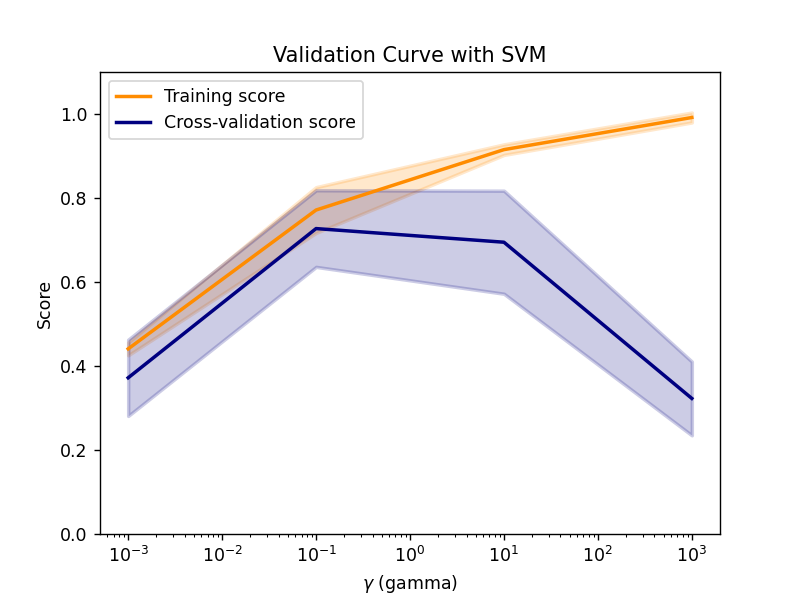

In [15]:
# This code based on scikit-learn validation_plot example
#  See:  http://scikit-learn.org/stable/auto_examples/model_selection/plot_validation_curve.html
#Figura
plt.figure()
#Media y desviación estándar  de los puntajes en los 3 folds para cada uno de los valores de gamma 
#tanto en el conjunto de prueba como en el de entrenamiento
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)
#Título y límites de la gráfica
plt.title('Validation Curve with SVM')
plt.xlabel('$\gamma$ (gamma)')
plt.ylabel('Score')
plt.ylim(0.0, 1.1)
lw = 2
#Gráfica en escala semilogarítmica de los valores de gama contra los promedios de los puntajes (muestra de entrenamiento)
plt.semilogx(param_range, train_scores_mean, label='Training score',
            color='darkorange', lw=lw)
#Valores asociados a la media más una desviación estándar, para obtener una especie de intervalo
plt.fill_between(param_range, train_scores_mean - train_scores_std,
                train_scores_mean + train_scores_std, alpha=0.2,
                color='darkorange', lw=lw)
#Similar pero para la muestra de entrenamiento
plt.semilogx(param_range, test_scores_mean, label='Cross-validation score',
            color='navy', lw=lw)

plt.fill_between(param_range, test_scores_mean - test_scores_std,
                test_scores_mean + test_scores_std, alpha=0.2,
                color='navy', lw=lw)

plt.legend(loc='best')
plt.show()